# AppVision Analytics · Launch Readiness Study
## 01 · Data rebuild

**Client:** Osu Lane Studio *(fictional)*, a five-person indie studio in Accra with budget to build one new Android app this year.

**The brief from the studio's founder:**
1. Which of our three app concepts has the best realistic odds?
2. What install number should year one be planned around, so marketing spend is set against something real?
3. What do the apps that broke out in each niche have in common?
4. Once we launch, how do we tell whether we're on track?

**This notebook:** Rebuilt the Google Play snapshot from the raw files into one clean table that feeds the model (notebook 03), the Playbook and the Benchmarks (notebook 04).

**Source:** *Google Play Store Apps* dataset by Gautham Prakash: 2,312,944 apps, 24 columns, scraped from the Play Store on 15–16 June 2021.

### What changed from the v1 pipeline

| Step | v1 | v2 |
|---|---|---|
| Missing values | Dropped every row with any blank field, which removed **44% of all apps** | Kept them; turned "has a website" and "has a privacy policy" into yes/no features |
| Personal data | Developer emails and URLs stayed in the CSV shipped with the app | Never loaded (emails) or reduced to yes/no flags (URLs) |
| "Varies with device" size | Filled with the category median | Kept as missing plus a flag, since it marks larger publishers |
| Target | Raw install count, dominated by a handful of billion-install apps | Five install bands on a log scale, defined once in `appvision/bands.py` |
| Developer history | Not used | How many apps the developer released earlier and how those performed |

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.csv as pacsv
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))

from appvision import bands, features, names
from appvision.style import use_notebook_style, BLUE, ORANGE, BAND_COLORS, INK_2, MUTED

use_notebook_style()
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

RAW_DIR = Path(r"C:\Users\USER\Documents\A Data Scientist Toolkit\Google-Playstore-Dataset-main\dataset")
OUT_DIR = REPO / "data" / "v2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

### 1 · Loaded the raw files
Read the three parts with pyarrow (about 1.2 GB on disk) and skipped the developer email column entirely. Website and privacy-policy URLs were reduced to yes/no flags as each part loaded, so no URL or email is held in memory or written out.

In [2]:
RAW_COLS = ["App Name", "App Id", "Category", "Rating", "Rating Count", "Installs", "Minimum Installs",
            "Maximum Installs", "Free", "Price", "Currency", "Size", "Minimum Android", "Developer Id",
            "Developer Website", "Developer Email", "Released", "Last Updated", "Content Rating",
            "Privacy Policy", "Ad Supported", "In App Purchases", "Editors Choice", "Scraped Time"]
LOAD_COLS = [c for c in RAW_COLS if c != "Developer Email"]

parts = []
for i in (1, 2, 3):
    table = pacsv.read_csv(
        RAW_DIR / f"Part{i}.csv",
        read_options=pacsv.ReadOptions(column_names=RAW_COLS, skip_rows=1 if i == 1 else 0, block_size=1 << 26),
        convert_options=pacsv.ConvertOptions(include_columns=LOAD_COLS),
    )
    part = table.to_pandas(types_mapper=pd.ArrowDtype)
    del table
    part["has_website"] = part.pop("Developer Website").fillna("").str.len() > 0
    part["has_privacy"] = part.pop("Privacy Policy").fillna("").str.len() > 0
    parts.append(part)
    print(f"Part{i}.csv: {len(part):,} apps")

raw = pd.concat(parts, ignore_index=True)
del parts
print(f"\nTotal: {len(raw):,} apps · duplicate app ids: {raw['App Id'].duplicated().sum()}")

Part1.csv: 799,999 apps


Part2.csv: 800,000 apps


Part3.csv: 712,945 apps



Total: 2,312,944 apps · duplicate app ids: 0


### 2 · Measured what v1's row-dropping cost
Rebuilt v1's filter: a row survived only if every field was filled in. Then compared the apps it kept with the apps it threw away.

In [3]:
def blank(col):
    s = raw[col]
    return s.isna() | (s.astype("string").fillna("").str.strip() == "") if s.dtype != bool else s.isna()

v1_kept = (raw["has_website"] & raw["has_privacy"]
           & ~blank("Released") & ~blank("Rating") & ~blank("Minimum Android") & ~blank("Developer Id")
           & ~blank("App Name") & ~blank("Size") & ~blank("Installs") & (raw["Currency"] != "XXX"))

installs_raw = raw["Maximum Installs"].astype("float64")
band_raw = bands.band_of(installs_raw)

summary = pd.DataFrame({
    "apps": [v1_kept.sum(), (~v1_kept).sum()],
    "median installs": [installs_raw[v1_kept].median(), installs_raw[~v1_kept].median()],
    "reached 10K+": [(installs_raw[v1_kept] >= 1e4).mean(), (installs_raw[~v1_kept] >= 1e4).mean()],
    "reached 100K+": [(installs_raw[v1_kept] >= 1e5).mean(), (installs_raw[~v1_kept] >= 1e5).mean()],
}, index=["kept by v1", "dropped by v1"])
print(f"v1 dropped {(~v1_kept).mean():.1%} of all apps")
summary.style.format({"apps": "{:,.0f}", "median installs": "{:,.0f}", "reached 10K+": "{:.1%}", "reached 100K+": "{:.1%}"})

v1 dropped 44.4% of all apps


,apps,median installs,reached 10K+,reached 100K+
kept by v1,"1,286,675",950,25.6%,10.2%
dropped by v1,"1,026,269",472,18.3%,5.2%


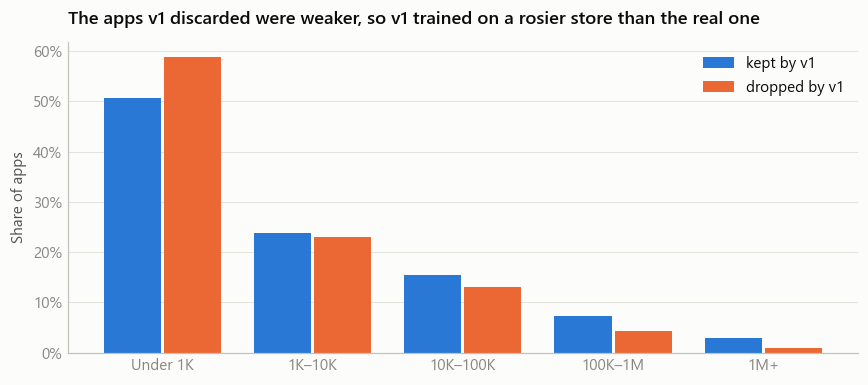

In [4]:
shares = pd.DataFrame({
    "kept by v1": pd.Series(band_raw[v1_kept.to_numpy()]).value_counts(normalize=True).sort_index().values,
    "dropped by v1": pd.Series(band_raw[~v1_kept.to_numpy()]).value_counts(normalize=True).sort_index().values,
}, index=bands.BAND_LABELS)

fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(shares))
w = 0.38
for j, (col, color) in enumerate([("kept by v1", BLUE), ("dropped by v1", ORANGE)]):
    ax.bar(x + (j - 0.5) * (w + 0.02), shares[col], width=w, color=color, label=col)
ax.set_xticks(x, shares.index)
ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax.set_ylabel("Share of apps")
ax.set_title("The apps v1 discarded were weaker, so v1 trained on a rosier store than the real one")
ax.legend(loc="upper right")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

**Result:** v1's filter removed about 1 million apps, mostly because they had no developer website. Those apps reach 10K installs noticeably less often, so v1 learned from a store that looked more successful than the real one. v2 kept them all.

### 3 · Cleaned and parsed every field
- **Size:** converted "10M", "512k" and "1.2G" to megabytes. "Varies with device" stayed missing with its own flag.
- **Minimum Android:** took the version number from text such as "4.0.3 and up", with the same flag for "Varies with device".
- **Price:** converted the 14 listed currencies to USD. Free apps priced in the unknown currency code "XXX" were set to $0; paid apps in "XXX" stayed missing.
- **Dates:** parsed release, last-update and scrape dates, then computed days on the store at the time of the scrape.
- **Age rating:** folded the 154 "Unrated" apps into "Everyone".

In [5]:
df = pd.DataFrame({
    "app_id": raw["App Id"].astype("string[pyarrow]"),
    "app_name": raw["App Name"].astype("string[pyarrow]"),
    "developer_id": raw["Developer Id"].astype("string[pyarrow]"),
    "category": raw["Category"].astype("string").astype(pd.CategoricalDtype(features.CATEGORIES)),
})
assert df["category"].notna().all(), "found a category outside the fixed list"

content = raw["Content Rating"].astype("string").replace({"Unrated": "Everyone"})
df["content_rating"] = content.astype(pd.CategoricalDtype(features.CONTENT_RATINGS))

df["free"] = raw["Free"].astype(bool).astype("int8")
fx = raw["Currency"].astype("string").map(features.FX_TO_USD).astype("float64")
price = raw["Price"].astype("float64")
df["price_usd"] = np.where(df["free"] == 1, 0.0, price * fx).astype("float32")

for flag in ["Ad Supported", "In App Purchases", "Editors Choice"]:
    df[flag.lower().replace(" ", "_")] = raw[flag].astype(bool).astype("int8")

df["size_mb"] = features.parse_size_mb(raw["Size"]).values
df["size_varies"] = (raw["Size"].astype("string") == "Varies with device").astype("int8").values
df["min_android"] = features.parse_min_android(raw["Minimum Android"]).values
df["min_android_varies"] = (raw["Minimum Android"].astype("string") == "Varies with device").astype("int8").values
df["has_website"] = raw["has_website"].astype("int8")
df["has_privacy"] = raw["has_privacy"].astype("int8")

released = pd.to_datetime(raw["Released"].astype("string"), format="%b %d, %Y", errors="coerce")
updated = pd.to_datetime(raw["Last Updated"].astype("string"), format="%b %d, %Y", errors="coerce")
scraped = pd.to_datetime(raw["Scraped Time"].astype("string"), errors="coerce")
df["released"] = released.values
df["age_days"] = (scraped - released).dt.days.astype("float32").values
df["days_since_update"] = (scraped - updated).dt.days.astype("float32").values

df["rating"] = raw["Rating"].astype("float32").values
df["rating_count"] = raw["Rating Count"].astype("float64").values
df["installs"] = installs_raw.values
df["installs_floor"] = raw["Minimum Installs"].astype("float64").values
df["band"] = band_raw.astype("int8")

print(f"Size parsed for {df['size_mb'].notna().mean():.1%} of apps ({df['size_varies'].mean():.1%} vary by device)")
print(f"Min Android parsed for {df['min_android'].notna().mean():.1%} of apps")
print(f"Paid apps with an unknown currency (price left missing): {df['price_usd'].isna().sum():,}")
print(f"Release date missing: {df['released'].isna().sum():,} apps ({df['released'].isna().mean():.1%})")
print(f"Released after the scrape date (bad dates): {(df['age_days'] < 0).sum():,}")

Size parsed for 96.8% of apps (3.2% vary by device)
Min Android parsed for 97.7% of apps
Paid apps with an unknown currency (price left missing): 135
Release date missing: 71,053 apps (3.1%)
Released after the scrape date (bad dates): 0


### 4 · Defined the target once: five install bands
Used *Maximum Installs*, which is the Play Store's own approximate install count for each app (the public "10,000+" label is the floor of its bucket). Raw counts run from 0 to 12 billion, so v1's error metrics were dominated by a handful of giant apps. v2 predicts which of five bands an app lands in. These bands are used everywhere: in the model, the benchmarks and every label in the app.

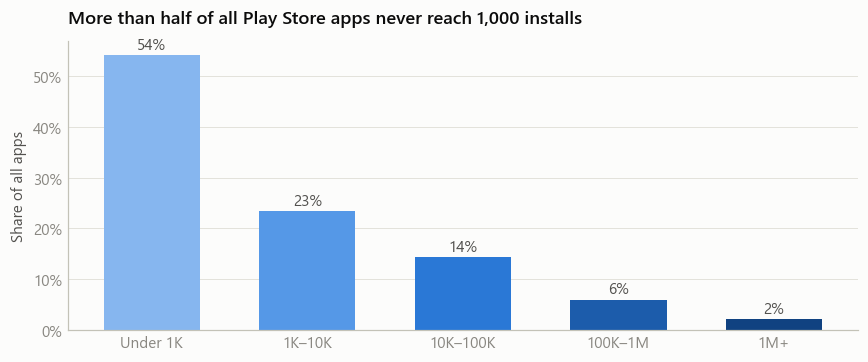

In [6]:
band_share = df["band"].value_counts(normalize=True).sort_index()
band_share.index = bands.BAND_LABELS

fig, ax = plt.subplots(figsize=(8, 3.4))
bars = ax.bar(band_share.index, band_share.values, color=BAND_COLORS, width=0.62)
for rect, v in zip(bars, band_share.values):
    ax.annotate(f"{v:.0%}", (rect.get_x() + rect.get_width() / 2, v), xytext=(0, 4),
                textcoords="offset points", ha="center", color=INK_2)
ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax.set_ylabel("Share of all apps")
ax.set_title("More than half of all Play Store apps never reach 1,000 installs")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

**Result:** This is the honest starting point for any launch conversation. The typical Play Store app ends up with about 700 installs, and only about 8% pass 100K. That top 8% is what this study calls a **breakout**.

### 5 · Added the studio's track record
For every app, counted how many apps the same developer had released **before** it, and averaged the installs of those earlier apps on a log scale. Apps released on the same day don't count as each other's history. A studio knows both numbers before it launches anything new, so they're fair inputs.

*Caveat, carried into the model notes:* the earlier apps' installs were measured in June 2021, not on the day the later app launched, so this feature slightly flatters developers whose catalogue kept growing.

In [7]:
prior_n, prior_log = features.developer_track_record(df["developer_id"], df["released"], df["installs"])
df["dev_prior_apps"] = prior_n
df["dev_prior_log_installs"] = prior_log
df["name_words"] = names.word_count(df["app_name"].to_numpy())

has_history = df["dev_prior_apps"] > 0
print(f"Apps whose developer had released something earlier: {has_history.mean():.1%}")
print("\nShare reaching 10K+ by the developer's earlier track record:")
track = pd.cut(df["dev_prior_log_installs"], [-1, 2, 3, 4, 5, 20],
               labels=["earlier apps < 100", "100–1K", "1K–10K", "10K–100K", "100K+"])
print((df["installs"] >= 1e4).groupby(track, observed=True).mean().map("{:.1%}".format).to_string())
print(f"(first app, no history): {(df.loc[~has_history, 'installs'] >= 1e4).mean():.1%}")

Apps whose developer had released something earlier: 63.5%

Share reaching 10K+ by the developer's earlier track record:
dev_prior_log_installs
earlier apps < 100     1.3%
100–1K                 4.0%
1K–10K                17.5%
10K–100K              50.6%
100K+                 81.7%
(first app, no history): 23.2%


### 6 · Checked how time on the store shapes outcomes
Installs pile up over time, and older apps in a snapshot are the ones that survived. So any fair comparison has to hold time on the store fixed. That's why the model takes **time since launch** as an input and the app asks for a horizon ("after 1 year", "after 2 years").

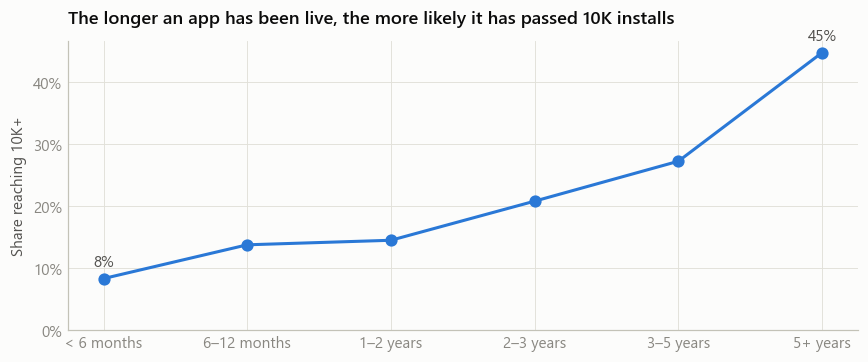

,apps,median installs,reached 10K+
age_days,,,
< 6 months,"199,029",100,8.3%
6–12 months,"258,729",281,13.7%
1–2 years,"559,851",306,14.5%
2–3 years,"378,852",726,20.8%
3–5 years,"499,780","1,360",27.2%
5+ years,"345,645","6,407",44.8%


In [8]:
age_bands = pd.cut(df["age_days"], [0, 182, 365, 730, 1095, 1825, 6000],
                   labels=["< 6 months", "6–12 months", "1–2 years", "2–3 years", "3–5 years", "5+ years"])
by_age = pd.DataFrame({
    "apps": df.groupby(age_bands, observed=True).size(),
    "median installs": df.groupby(age_bands, observed=True)["installs"].median(),
    "reached 10K+": (df["installs"] >= 1e4).groupby(age_bands, observed=True).mean(),
})

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(by_age.index.astype(str), by_age["reached 10K+"], marker="o", markersize=7, color=BLUE)
for xi, v in enumerate(by_age["reached 10K+"]):
    if xi in (0, len(by_age) - 1):
        ax.annotate(f"{v:.0%}", (xi, v), xytext=(0, 8), textcoords="offset points", ha="center", color=INK_2)
ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax.set_ylim(0, None)
ax.set_ylabel("Share reaching 10K+")
ax.set_title("The longer an app has been live, the more likely it has passed 10K installs")
plt.tight_layout()
plt.show()
by_age.style.format({"apps": "{:,.0f}", "median installs": "{:,.0f}", "reached 10K+": "{:.1%}"})

### 7 · Saved the clean table
Wrote one Parquet file with only the columns later notebooks need. It holds no emails or URLs and isn't committed to git, because it's large. The app ships much smaller derived files instead (notebooks 03 and 04).

In [9]:
df["in_model"] = (df["released"].notna() & (df["age_days"] >= 0)).astype("int8")
out_path = OUT_DIR / "apps_2021.parquet"
df.to_parquet(out_path, index=False, compression="zstd")
print(f"Saved {len(df):,} apps × {df.shape[1]} columns → {out_path.relative_to(REPO)} "
      f"({out_path.stat().st_size / 1e6:.0f} MB)")
print(f"Usable for modelling (valid release date): {df['in_model'].sum():,} apps")
df.drop(columns=["app_name", "developer_id", "app_id"]).head()

Saved 2,312,944 apps × 28 columns → data\v2\apps_2021.parquet (142 MB)
Usable for modelling (valid release date): 2,241,891 apps


,category,content_rating,free,price_usd,ad_supported,in_app_purchases,editors_choice,size_mb,size_varies,min_android,...,days_since_update,rating,rating_count,installs,installs_floor,band,dev_prior_apps,dev_prior_log_installs,name_words,in_model
0,Adventure,Everyone,1,0.000,0,0,0,10.000,0,7.100,...,475.000,0.000,0.000,15.000,10.000,0,0.000,NaN,1.000,1
1,Tools,Everyone,1,0.000,1,0,0,2.900,0,5.000,...,40.000,4.400,64.000,"7,662.000","5,000.000",1,9.000,2.997,3.000,1
2,Productivity,Everyone,1,0.000,0,0,0,3.700,0,4.000,...,666.000,0.000,0.000,58.000,50.000,0,2.000,2.737,1.000,1
3,Communication,Everyone,1,0.000,1,0,0,1.800,0,4.000,...,976.000,5.000,5.000,19.000,10.000,0,0.000,NaN,7.000,1
4,Tools,Everyone,1,0.000,0,0,0,6.200,0,4.100,...,946.000,0.000,0.000,478.000,100.000,0,0.000,NaN,1.000,1


### Takeaways for the studio
- **The baseline is sobering:** 54% of apps stay under 1,000 installs and only about 8% become breakouts (100K+). Every number later in this study should be read against that.
- **Time on the store matters a lot.** Comparisons in this study always hold it fixed.
- **The v1 data overstated success,** because it silently dropped about a million weaker apps. Everything downstream now uses the full store.